# SVM for classification

Load IRIS dataset, check its contents:


In [1]:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
#print(iris.feature_names)
#print(iris.data[0:5,:])
print(iris.target[0:5])
#print(iris.data)

[0 0 0 0 0]


Split data into training and testing parts:

In [2]:
from sklearn.model_selection import train_test_split
X=iris.data
y=iris.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


Use a Support Vector Machine for classification:


In [3]:
from sklearn.svm import SVC
SVMmodel=SVC(kernel='linear')
SVMmodel.fit(X_train,y_train)
SVMmodel.get_params()
SVMmodel.score(X_test,y_test)

1.0

Let's explore more now.

*   Choose only first two features (columns) of iris.data
*   SVM is in its basic form a 2-class classifier, so eliminate iris.target =2 from the data



In [4]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

X = X[:, :2]

X, y = X[y < 2], y[y < 2]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(X_train.shape)
print(np.unique(y))

(80, 2)
[0 1]


Plot scatterplots of targets 0 and 1 and check the separability of the classes:

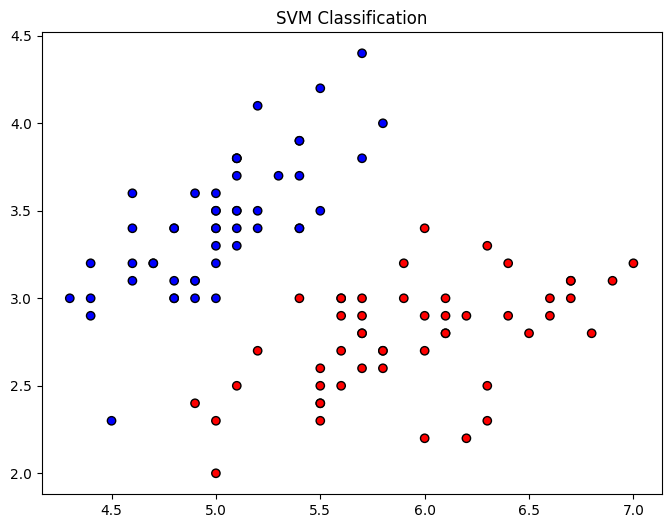

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.title('SVM Classification')
plt.show()

Train and test the SVM classifier, play with regularization parameter C (either use the default value or try e.g. 200)

In [6]:
from sklearn.svm import SVC

C_param = 1
#C_param = 200
SVMmodel = SVC(kernel='linear', C=C_param)
SVMmodel.fit(X_train, y_train)

score = SVMmodel.score(X_test, y_test)
print(score)

1.0


Show support vectors in the 2D plot, plot the decision line from equation [w0 w1]*[x0 x1] + b = 0:

[ 2.22093121 -2.22161731]
-4.9951667102208


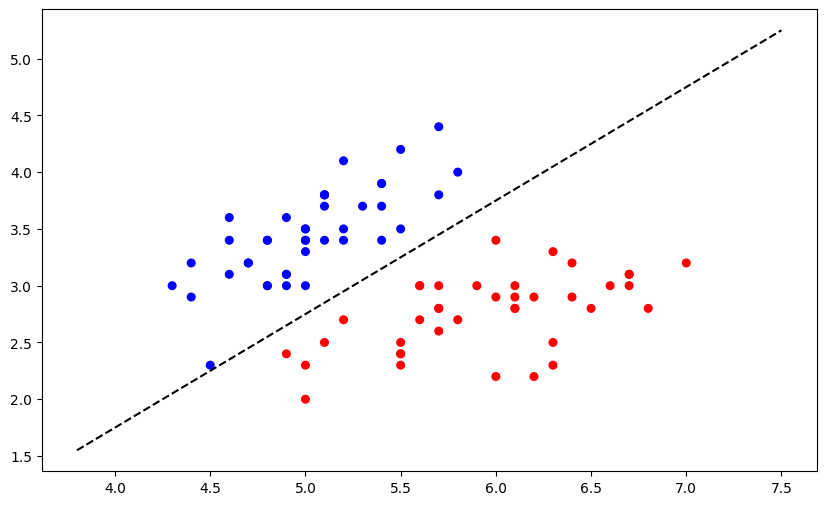

In [7]:
W = SVMmodel.coef_[0]
b = SVMmodel.intercept_[0]
print(W)
print(b)
supvectors = SVMmodel.support_vectors_

plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', s=30)

x0_min, x0_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5

x1_min = -(W[0] * x0_min + b) / W[1]
x1_max = -(W[0] * x0_max + b) / W[1]

plt.plot([x0_min, x0_max], [x1_min, x1_max], 'k--')
plt.show()

# Anomaly detection via SVM

Import one-class SVM and generate data (Gaussian blobs in 2D-plane):

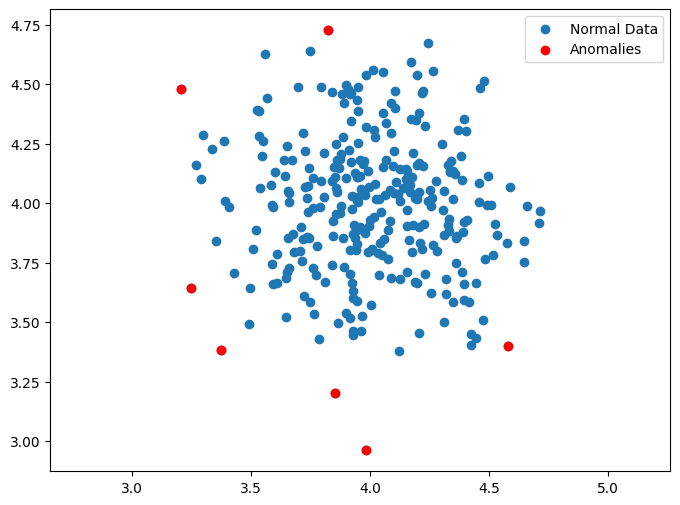

In [8]:
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from numpy import quantile, where, random

random.seed(11)
x, _ = make_blobs(n_samples=300, centers=1, cluster_std=.3, center_box=(4, 4))

SVMmodelOne = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.03)
SVMmodelOne.fit(x)

pred = SVMmodelOne.predict(x)
anom_index = where(pred == -1)
values = x[anom_index]

plt.figure(figsize=(8,6))
plt.scatter(x[:,0], x[:,1], label="Normal Data")
plt.scatter(values[:,0], values[:,1], color='red', label="Anomalies")
plt.axis('equal')
plt.legend()
plt.show()

Train one-class SVM and plot the outliers (outputs of prediction being equal to -1)

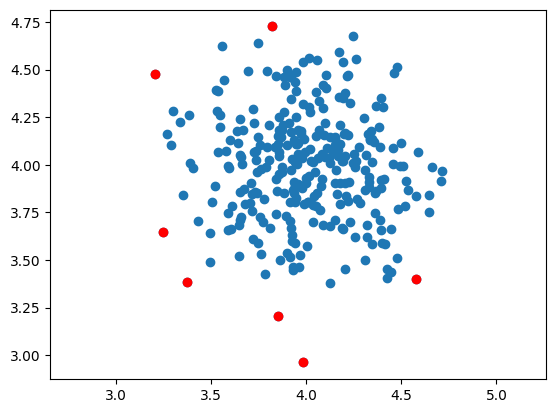

In [9]:
SVMmodelOne = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.03)


SVMmodelOne.fit(x)
pred = SVMmodelOne.predict(x)
anom_index = where(pred==-1)
values = x[anom_index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()



Plot the support vectors:

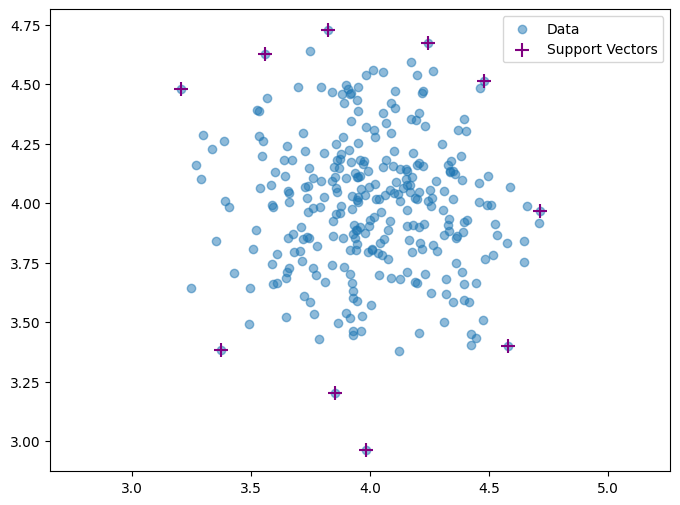

In [10]:
index_sv = SVMmodelOne.support_
sv_values = x[index_sv]

plt.figure(figsize=(8,6))
plt.scatter(x[:,0], x[:,1], alpha=0.5, label="Data")
plt.scatter(sv_values[:,0], sv_values[:,1], color='purple', marker='+', s=100, label="Support Vectors")

plt.axis('equal')
plt.legend()
plt.show()

What if we want to have a control what is outlier? Use e.g. 5% "quantile" to mark the outliers. Every point with lower score than threshold will be an outlier.

8.987833799021839


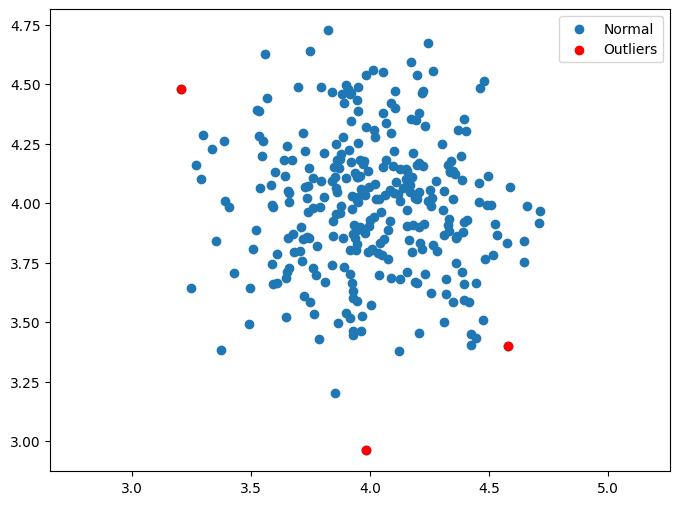

In [11]:
scores = SVMmodelOne.score_samples(x)

thresh = quantile(scores, 0.01)
print(thresh)

index = where(scores <= thresh)
values = x[index]

plt.figure(figsize=(8,6))
plt.scatter(x[:,0], x[:,1], label="Normal")
plt.scatter(values[:,0], values[:,1], color='red', label="Outliers")
plt.axis('equal')
plt.legend()
plt.show()